# Transfer Learning

## What is Transfer Learning?

Transfer learning is a machine learning technique where a model trained on one task is reused for another related task.

Instead of training a deep learning model from scratch, we take a **pretrained model** (trained on a large dataset) and adapt it to a new problem.

This works because deep neural networks learn **general features** that are useful for many tasks.

---

## Intuition

Training a deep learning model from scratch:

Input Image → CNN → Learn Features → Classification

With transfer learning:

Input Image → Pretrained CNN → Extract Features → New Classifier

The pretrained network already knows how to detect patterns like edges, shapes, and textures.

---

## Example

Consider a CNN trained on the **ImageNet dataset**.

ImageNet contains:
- Over 14 million images
- 1000 object categories

During training, the network learns important visual features such as:
- edges
- corners
- shapes
- textures
- object parts

These features can be reused for new tasks like:
- Cat vs Dog classification
- Medical image diagnosis
- Face recognition
- Plant disease detection

---

## Why Transfer Learning is Useful

Training deep learning models from scratch requires:

- Large datasets
- High computational power
- Long training time

Transfer learning helps when:

- The dataset is small
- Training resources are limited
- A pretrained model already exists

Benefits:

- Faster training
- Requires less data
- Often achieves higher accuracy

---

## Types of Transfer Learning

### 1. Feature Extraction

The pretrained network is used as a **fixed feature extractor**.

Steps:
1. Load a pretrained model
2. Remove the final classification layers
3. Freeze the convolutional layers
4. Train a new classifier on extracted features

Example pipeline:

Image → VGG16 → Feature Vector → Dense Layer / SVM → Prediction

---

### 2. Fine-Tuning

Fine-tuning involves retraining part of the pretrained network.

Steps:
1. Load pretrained model
2. Freeze early layers
3. Retrain deeper layers
4. Add a new classifier

This allows the model to adapt better to the new dataset.

---

## Why Early Layers are Reused

In CNNs, layers learn features hierarchically.

Layer 1 → edges  
Layer 2 → corners  
Layer 3 → shapes  
Layer 4 → object parts  
Layer 5 → complete objects  

Early layers learn **general patterns**, so they can be reused across many tasks.

---

## Popular Pretrained Models

Common models used for transfer learning:

- VGG16
- ResNet
- Inception
- MobileNet
- EfficientNet

These models are usually trained on the **ImageNet dataset**.

---

## Typical Transfer Learning Workflow

1. Load pretrained model
2. Remove the top classification layers
3. Freeze convolution layers
4. Add new classifier layers
5. Train on new dataset
6. Evaluate model performance

---

## Summary

Transfer learning allows us to reuse knowledge learned from large datasets to solve new problems efficiently.

It reduces training time, requires less data, and often improves performance on small datasets.

## Objective of This Notebook

In this notebook, we demonstrate **Transfer Learning for image classification** using a pretrained convolutional neural network (VGG16).

Instead of training a deep neural network from scratch, we use a **model that has already been trained on a large dataset (ImageNet)** to extract meaningful features from images.

The pretrained CNN is used as a **feature extractor**, and these extracted features are then used to train a classifier (such as a neural network or SVM) to distinguish between **cats and dogs**.

This approach allows us to build an accurate image classifier **with a smaller dataset and much faster training time** compared to training a deep network from scratch.

In [1]:
!wget https://www.dropbox.com/s/y9hooknj3zmeqmw/data.zip #wget is command line tool used to fetch files from internet
# whenever you run shell command from jupter notebook you use !

--2026-04-04 04:02:49--  https://www.dropbox.com/s/y9hooknj3zmeqmw/data.zip
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18, 2620:100:6030:18::a27d:5012
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/ddwztkg6rfk1gxoq2kpc9/data.zip?rlkey=db25q8ynufq3b8xw64buh31ml [following]
--2026-04-04 04:02:50--  https://www.dropbox.com/scl/fi/ddwztkg6rfk1gxoq2kpc9/data.zip?rlkey=db25q8ynufq3b8xw64buh31ml
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uceeeea36e3b0d4fa9836891f8bc.dl.dropboxusercontent.com/cd/0/inline/C96jc54mapED6aJZeMzAD9jKwJ3s9VUdxRE6GIf0G0se8FqH0ex8-CQMPh7UrSmcgHniPSxHZ2DHEElG5zzCiv3wLg6uDNK0jqJ_w1MbzINfi4s1R6E-s7ETfKOkPrfGRZaAyhD9z--ktmRoBGY7y5z2/file# [following]
--2026-04-04 04:02:51--  https://uceeeea36e3b0d4fa9836891f8bc.dl.dropboxusercontent.com/cd/0/inline/C96jc54map

In [3]:
#!unzip data.zip

In [7]:
# Base variables
import os
base_dir = '/content/data'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')

train_size, validation_size, test_size = 200, 100, 100

img_width, img_height = 224, 224  # Default input size for VGG16

In [5]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
train_dir

'/content/data/train'

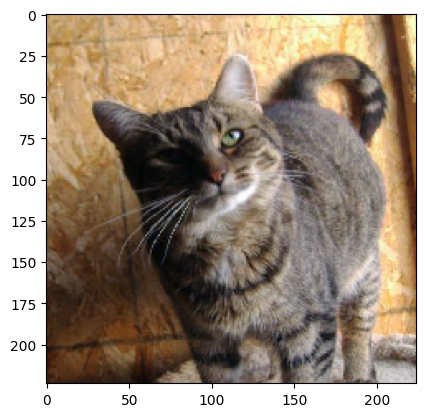

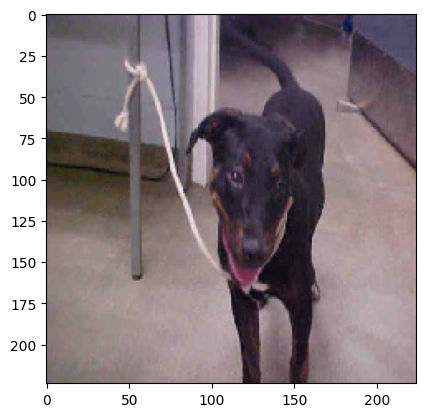

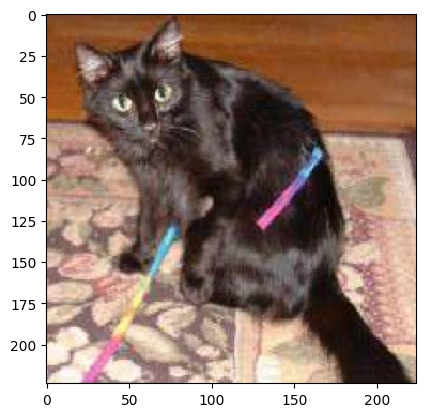

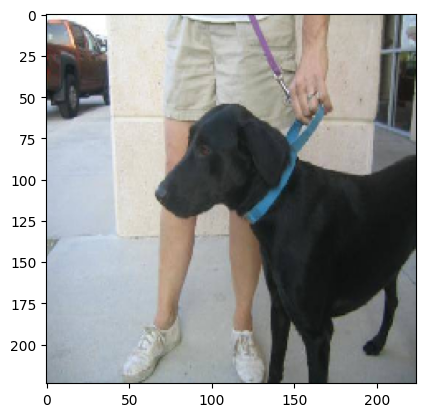

In [8]:
# Show pictures
import os, random
import matplotlib.pyplot as plt
import numpy as np
from keras.preprocessing import image

def show_pictures(path):
    random_img = random.choice(os.listdir(path)) #randomly selects one image
    img_path = os.path.join(path, random_img) #set path of that image

    img = image.load_img(img_path, target_size=(img_width, img_height))
    img_tensor = image.img_to_array(img)  # Image data encoded as integers in the 0–255 range
    img_tensor /= 255.  # Normalize to [0,1] for plt.imshow application
    plt.imshow(img_tensor)
    plt.show()

for i in range(0,2):
    show_pictures(train_cats_dir)
    show_pictures(train_dogs_dir)

In [ ]:
# Instantiate convolutional base
from keras.applications import VGG16

conv_base = VGG16(weights='imagenet',
                  include_top=False, #dont want fully connected NN of VGG16
                  input_shape=(img_width, img_height, 3))  # 3 = number of channels in RGB pictures

In [ ]:
#help(VGG16)

In [ ]:
# Check architecture
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
train_size

200

ImageDataGenerator is a class in keras

1. Load images from a folder
2. Preprocess image
3. Normalize pixel values
4. Generate batches of images for trainig

Instead of loading all images into memory, it loads them batch by batch

In [ ]:
#help(ImageDataGenerator)

In [ ]:
# Extract features
import os, shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255) #divide all pixels values by 255 -> [1 and 1]
batch_size = 32 #instead of feeding all images at once, model processes 32 images at a time

def extract_features(directory, sample_count):
    #1. Read images from directory
    #2. Pass those images through pretrained VGG model
    #3. Extract the features

    features = np.zeros(shape=(sample_count, 7, 7, 512))  #creating empty array to save the feature maps #7*7*512 is the last layer output shape
    # Must be equal to the output of the convolutional base
    labels = np.zeros(shape=(sample_count))
    # Preprocess data
    generator = datagen.flow_from_directory(directory,
                                            target_size=(img_width,img_height), #NN require fixed size input
                                            batch_size = batch_size,
                                            class_mode='binary') #2 classes only
    #flow_from_directory -> 1. read images from folder; 2. resize them 3. create batches 4. Assign labels
    # Folder structure required -> dataset -> 2 folders for 2 classes...cats and dogs -> inside cats folder there would be cat image.....

    # Pass data through convolutional base
    i = 0
    #looping over each batch
    for inputs_batch, labels_batch in generator: #inputs_batch-> batches of 32 images
        features_batch = conv_base.predict(inputs_batch) #predict method will give us feature map in output
        features[i * batch_size: (i + 1) * batch_size] = features_batch # size of features_batch 32, 7, 7, 512
        labels[i * batch_size: (i + 1) * batch_size] = labels_batch
        i += 1
        if i * batch_size >= sample_count:
            break
    return features, labels

train_features, train_labels = extract_features(train_dir, train_size)  # Agree with our small dataset size
validation_features, validation_labels = extract_features(validation_dir, validation_size)
test_features, test_labels = extract_features(test_dir, test_size)

Found 200 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
Found 100 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step
Found 100 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


In [ ]:
# Define model
from keras import models
from keras import layers
from keras import optimizers

epochs = 100

#defining the architecture

model = models.Sequential()
model.add(layers.Flatten(input_shape=(7,7,512))) #feature map of each image is of size 7*7*512
model.add(layers.Dense(256, activation='relu')) #hidden 256 neurons
model.add(layers.Dropout(0.5)) #dropout
model.add(layers.Dense(1, activation='sigmoid')) #output P(cat) = 1- P(dog)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,423,041 (24.50 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile model
model.compile(optimizer=optimizers.Adam(),
              loss='binary_crossentropy',
              metrics=['acc'])

In [ ]:
# Train the model
history = model.fit(train_features, train_labels, #output of convolution layer (VGG16) is passed as input to this model
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(validation_features, validation_labels))

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 275ms/step - acc: 0.4392 - loss: 3.9682 - val_acc: 0.6700 - val_loss: 0.6340
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.5706 - loss: 0.9255 - val_acc: 0.8300 - val_loss: 0.5156
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - acc: 0.7445 - loss: 0.5151 - val_acc: 0.8400 - val_loss: 0.5103
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.8777 - loss: 0.3915 - val_acc: 0.8300 - val_loss: 0.4781
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - acc: 0.9182 - loss: 0.3337 - val_acc: 0.8500 - val_loss: 0.4464
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9203 - loss: 0.2576 - val_acc: 0.8200 - val_loss: 0.4152
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9496 - loss: 0.2015 - val_acc: 0.8400 - val_loss: 0.3947
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - acc: 0.9232 - loss: 0.2057 - val_acc: 0.8400 - val_loss: 0.3948
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9505 - loss:

In [ ]:
# Define function to visualize predictions
def visualize_predictions(classifier, n_cases):
    for i in range(0,n_cases):
        path = random.choice(['/content/data/test/cats', '/content/data/test/dogs']) #randomly selecting 5 images

        # Get picture
        random_img = random.choice(os.listdir(path))
        img_path = os.path.join(path, random_img)
        img = image.load_img(img_path, target_size=(img_width, img_height))
        img_tensor = image.img_to_array(img)  # Image data encoded as integers in the 0–255 range
        img_tensor /= 255.  # Normalize to [0,1] for plt.imshow application

        # Extract features
        features = conv_base.predict(img_tensor.reshape(1,img_width, img_height, 3))

        # Make prediction
        try:
            prediction = classifier.predict(features)
        except:
            prediction = classifier.predict(features.reshape(1, 7*7*512))

        # Show picture
        plt.imshow(img_tensor)
        plt.show()

        # Write prediction
        if prediction < 0.5:
            print('Cat')
        else:
            print('Dog')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


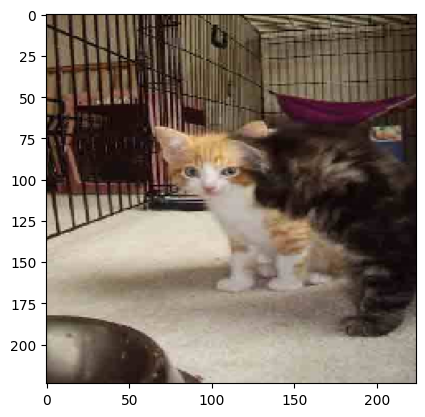

Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


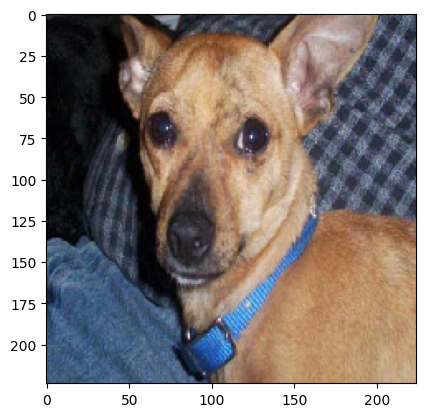

Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


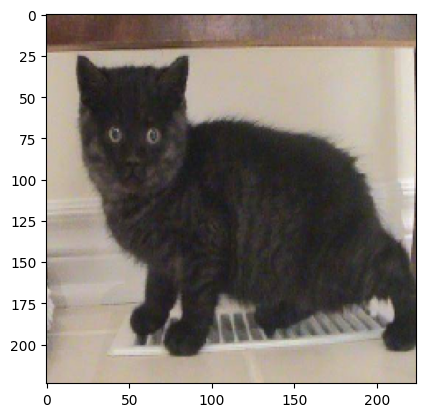

Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


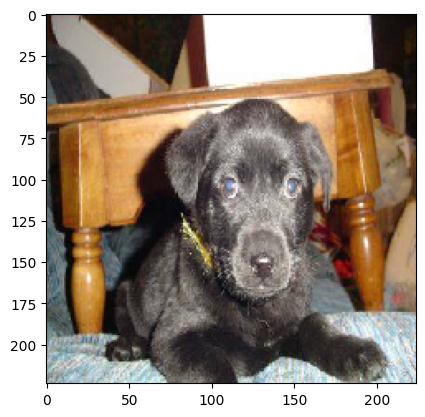

Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


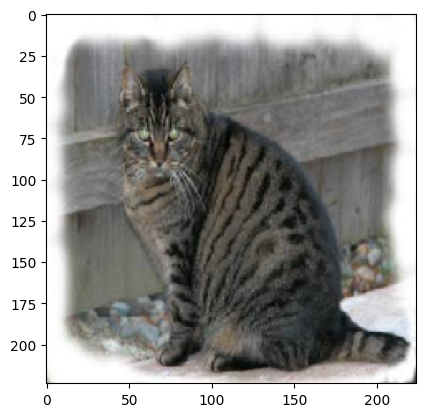

Cat


In [ ]:
# Visualize predictions
visualize_predictions(model, 5)